In [1]:
# Cell 1: Environment Setup & Execution Configuration
import os
import sys
import re
from pathlib import Path
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Ensure src/ is on sys.path to reuse doc_agent package modules directly
possible_src = [Path("../src"), Path("src"), Path("../../src")]
src_dir = next((d.resolve() for d in possible_src if (d / "doc_agent").is_dir()), None)
if src_dir and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from doc_agent.contracts import Page, Region
from doc_agent.vision import layout

# Ensure Windows console / notebooks handle Bengali UTF-8 encoding safely
if sys.stdout and hasattr(sys.stdout, 'reconfigure'):
    try:
        sys.stdout.reconfigure(encoding='utf-8', errors='replace')
    except Exception:
        pass

# -------------------------------------------------------------------------
# Execution Configuration:
# Set RUN_ON_SUBSET = True for fast local prototyping / testing.
# Set RUN_ON_SUBSET = False on Kaggle / full compute to process all 704 pages.
# -------------------------------------------------------------------------
RUN_ON_SUBSET = True

# Representative sample pages across geometry, algebra, trigonometry
SUBSET_PAGES = [7, 10, 16, 42, 45, 70, 72, 74, 75, 76, 120, 165, 215, 260, 310]
SUBSET_SAMPLE_SIZE = 16

# Resolve RAW_DATA_DIR relative to notebook or repo root
possible_dirs = [Path("../data/raw"), Path("data/raw"), Path("data")]
RAW_DATA_DIR = next((d for d in possible_dirs if d.is_dir() and any(d.glob("*.png"))), Path("../data/raw"))

print(f"[Setup] Raw Data Directory : {RAW_DATA_DIR.resolve()}")
print(f"[Setup] Package Source Dir : {src_dir}")
print(f"[Setup] Mode                : {'SUBSET MODE (Local Test)' if RUN_ON_SUBSET else 'FULL SCAN (704 pages)'}")



[Setup] Raw Data Directory : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\raw
[Setup] Mode                : SUBSET MODE (Local Test)


In [2]:
# Cell 2: Chapter Taxonomy & Content-Type Mappings

gmath_chapters = {
    "toc": (5, 5),
    "chap1": (6, 25),
    "chap2": (26, 47),
    "chap3": (48, 79),
    "chap4": (80, 97),
    "chap5": (98, 115),
    "chap6": (116, 140),
    "chap7": (141, 156),
    "chap8": (157, 178),
    "chap9": (179, 201),
    "chap10": (202, 209),
    "chap11": (210, 228),
    "chap12": (229, 253),
    "chap13": (254, 270),
    "chap14": (271, 289),
    "chap15": (290, 298),
    "chap16": (299, 330),
    "chap17": (331, 349),
    "answers": (350, 359),
    "appendix": (360, 385),
    "mathematicians": (386, 389),
}

hmath_chapters = {
    "toc": (5, 5),
    "chap1": (6, 42),
    "chap2": (43, 67),
    "chap3": (68, 86),
    "chap4": (87, 100),
    "chap5": (101, 127),
    "chap6": (128, 140),
    "chap7": (141, 150),
    "chap8": (151, 197),
    "chap9": (198, 227),
    "chap10": (228, 243),
    "chap11": (244, 275),
    "chap12": (276, 291),
    "chap13": (292, 310),
    "chap14": (311, 320),
    "answers": (321, 332),
    "mathematicians": (333, 337),
    "appendix": (338, 338),
}

GMATH_METADATA = {
    "toc": {"name_bn": "সূচিপত্র", "name_en": "Table of Contents", "content_type": "Reference"},
    "chap1": {"name_bn": "বাস্তব সংখ্যা", "name_en": "Real Numbers", "content_type": "Algebra & Formulas"},
    "chap2": {"name_bn": "সেট ও ফাংশন", "name_en": "Sets and Functions", "content_type": "Algebra & Sets"},
    "chap3": {"name_bn": "বীজগাণিতিক রাশি", "name_en": "Algebraic Expressions", "content_type": "Algebra & Formulas"},
    "chap4": {"name_bn": "সূচক ও লগারিদম", "name_en": "Exponents and Logarithms", "content_type": "Algebra & Formulas"},
    "chap5": {"name_bn": "এক চলকবিশিষ্ট সমীকরণ", "name_en": "Equations in One Variable", "content_type": "Algebra & Formulas"},
    "chap6": {"name_bn": "রেখা, কোণ ও ত্রিভুজ", "name_en": "Lines, Angles and Triangles", "content_type": "Geometry & Diagrams"},
    "chap7": {"name_bn": "ব্যবহারিক জ্যামিতি", "name_en": "Practical Geometry", "content_type": "Geometry & Diagrams"},
    "chap8": {"name_bn": "বৃত্ত", "name_en": "Circles", "content_type": "Geometry & Diagrams"},
    "chap9": {"name_bn": "ত্রিকোণমিতিক অনুপাত", "name_en": "Trigonometric Ratios", "content_type": "Trigonometry"},
    "chap10": {"name_bn": "দূরত্ব ও উচ্চতা", "name_en": "Distance and Elevation", "content_type": "Trigonometry & Diagrams"},
    "chap11": {"name_bn": "বীজগাণিতিক অনুপাত ও সমানুপাত", "name_en": "Algebraic Ratio and Proportion", "content_type": "Algebra & Formulas"},
    "chap12": {"name_bn": "দুই চলকবিশিষ্ট সরল সহসমীকরণ", "name_en": "Simultaneous Equations", "content_type": "Algebra & Formulas"},
    "chap13": {"name_bn": "সসীম ধারা", "name_en": "Finite Series", "content_type": "Algebra & Formulas"},
    "chap14": {"name_bn": "অনুপাত, সদৃশতা ও প্রতিসমতা", "name_en": "Ratio, Similarity & Symmetry", "content_type": "Geometry & Diagrams"},
    "chap15": {"name_bn": "ক্ষেত্রফল সম্পর্কিত উপপাদ্য ও সম্পাদ্য", "name_en": "Area Theorems", "content_type": "Geometry & Diagrams"},
    "chap16": {"name_bn": "পরিমিতি", "name_en": "Mensuration", "content_type": "Geometry & Formulas"},
    "chap17": {"name_bn": "পরিসংখ্যান", "name_en": "Statistics", "content_type": "Tables & Statistics"},
    "answers": {"name_bn": "উত্তরমালা", "name_en": "Exercise Answers", "content_type": "Reference & Answers"},
    "appendix": {"name_bn": "পরিশिष्ट", "name_en": "Appendix", "content_type": "Reference"},
    "mathematicians": {"name_bn": "গণিতবিদদের পরিচিতি", "name_en": "Mathematicians Biography", "content_type": "Reference"},
}

HMATH_METADATA = {
    "toc": {"name_bn": "সূচিপত্র", "name_en": "Table of Contents", "content_type": "Reference"},
    "chap1": {"name_bn": "সেট ও ফাংশন", "name_en": "Sets and Functions", "content_type": "Algebra & Sets"},
    "chap2": {"name_bn": "বীজগাণিতিক রাশি", "name_en": "Algebraic Expressions", "content_type": "Algebra & Formulas"},
    "chap3": {"name_bn": "জ্যামিতি", "name_en": "Geometry Theorems", "content_type": "Geometry & Diagrams"},
    "chap4": {"name_bn": "জ্যামিতিক অঙ্কন", "name_en": "Geometric Constructions", "content_type": "Geometry & Diagrams"},
    "chap5": {"name_bn": "সমীকরণ", "name_en": "Equations", "content_type": "Algebra & Formulas"},
    "chap6": {"name_bn": "অসমতা", "name_en": "Inequalities", "content_type": "Algebra & Formulas"},
    "chap7": {"name_bn": "অসীম ধারা", "name_en": "Infinite Series", "content_type": "Algebra & Formulas"},
    "chap8": {"name_bn": "ত্রিকোণমিতি", "name_en": "Trigonometry", "content_type": "Trigonometry"},
    "chap9": {"name_bn": "সূচকীয় ও লগারিদমীয় ফাংশন", "name_en": "Exponential & Log Functions", "content_type": "Algebra & Formulas"},
    "chap10": {"name_bn": "দ্বিপদী বিস্তার", "name_en": "Binomial Expansion", "content_type": "Algebra & Formulas"},
    "chap11": {"name_bn": "স্থানাঙ্ক জ্যামিতি", "name_en": "Coordinate Geometry", "content_type": "Geometry & Coordinates"},
    "chap12": {"name_bn": "সমতলীয় ভেক্টর", "name_en": "Planar Vectors", "content_type": "Vectors & Diagrams"},
    "chap13": {"name_bn": "ঘন জ্যামিতি", "name_en": "Solid Geometry", "content_type": "Geometry & Diagrams"},
    "chap14": {"name_bn": "সম্ভাবনা", "name_en": "Probability", "content_type": "Tables & Statistics"},
    "answers": {"name_bn": "উত্তরমালা", "name_en": "Exercise Answers", "content_type": "Reference & Answers"},
    "mathematicians": {"name_bn": "গণিতবিদদের পরিচিতি", "name_en": "Mathematicians Biography", "content_type": "Reference"},
    "appendix": {"name_bn": "পরিশিষ্ট", "name_en": "Appendix", "content_type": "Reference"},
}

def lookup_chapter(book_type: str, page_num: int):
    ch_dict = gmath_chapters if book_type == "General Math" else hmath_chapters
    meta_dict = GMATH_METADATA if book_type == "General Math" else HMATH_METADATA
    for ch_key, (start_p, end_p) in ch_dict.items():
        if start_p <= page_num <= end_p:
            meta = meta_dict.get(ch_key, {"name_bn": ch_key, "name_en": ch_key, "content_type": "General"})
            return ch_key, meta["name_bn"], meta["name_en"], meta["content_type"]
    return "other", "অন্যান্য", "Other", "General"

print("[Taxonomy] Loaded chapter mappings for General Math and Higher Math.")


[Taxonomy] Loaded chapter mappings for General Math and Higher Math.


In [3]:
# Cell 3: Corpus Inventory & Page DataFrame Construction
image_paths = sorted(list(RAW_DATA_DIR.glob("*.png")))
records = []

for p in image_paths:
    fname = p.name
    size_kb = p.stat().st_size / 1024.0
    if fname.startswith("higher_math_"):
        book = "Higher Math"
        m = re.search(r"page_(\d+)", fname)
        page_num = int(m.group(1)) if m else 0
    else:
        book = "General Math"
        m = re.search(r"page_(\d+)", fname)
        page_num = int(m.group(1)) if m else 0
    
    ch_id, ch_bn, ch_en, content_type = lookup_chapter(book, page_num)
    records.append({
        "filename": fname,
        "path": str(p),
        "book": book,
        "page_num": page_num,
        "chapter_id": ch_id,
        "chapter_name_bn": ch_bn,
        "chapter_name_en": ch_en,
        "content_type": content_type,
        "size_kb": size_kb
    })

df_corpus = pd.DataFrame(records)
total_pages = len(df_corpus)
total_disk_mb = df_corpus["size_kb"].sum() / 1024.0

print(f"Total Pages: {total_pages} | Disk Size: {total_disk_mb:.2f} MB")

# Select active working subset
if RUN_ON_SUBSET:
    if SUBSET_PAGES:
        active_df = df_corpus[df_corpus["page_num"].isin(SUBSET_PAGES)].copy()
    else:
        active_df = df_corpus.sample(n=min(SUBSET_SAMPLE_SIZE, len(df_corpus)), random_state=42).copy()
    print(f"[Active Set] Using {len(active_df)} sample pages for local test.")
else:
    active_df = df_corpus.copy()
    print(f"[Active Set] Using all {len(active_df)} pages for full evaluation.")


Total Pages: 704 | Disk Size: 289.31 MB
[Active Set] Using 30 sample pages for local test.


In [4]:
# Cell 4: Parameterized Region Segmenter (Reusing doc_agent.vision.layout)

# Global Calibrated Configuration Dictionary (overridden interactively in Cell 5)
CALIBRATED_LAYOUT_CONFIG = {
    "min_fig_area": 12000,
    "fig_fill_thresh": 0.20,
    "fig_pad": 25,
    "kh_ratio": 0.038,
    "heading_factor": 1.45,
    "math_indent_ratio": 0.05,
    "math_fill_thresh": 0.14,
    "pad_y": 10,
    "pad_x": 12,
}

def segment_page_regions(
    img_path: str,
    min_fig_area: int = 12000,
    fig_fill_thresh: float = 0.20,
    fig_pad: int = 25,
    kh_ratio: float = 0.038,
    heading_factor: float = 1.45,
    math_indent_ratio: float = 0.05,
    math_fill_thresh: float = 0.14,
    pad_y: int = 10,
    pad_x: int = 12,
):
    """Reuses doc_agent.vision.layout.detect to extract regions and compute EDA summary metrics."""
    p_path = Path(img_path)
    if not p_path.is_file():
        return {"regions": [], "num_headings": 0, "num_text": 0, "num_math": 0, "num_figures": 0, "num_tables": 0, "est_words": 0, "units": {}}

    doc_id = "higher_math" if "higher" in p_path.stem else "general_math"
    page = Page(id=f"{doc_id}__{p_path.stem}", image_path=str(p_path), doc_id=doc_id)

    cfg = {
        "layout": {
            "min_fig_area": min_fig_area,
            "fig_fill_thresh": fig_fill_thresh,
            "fig_pad": fig_pad,
            "kh_ratio": kh_ratio,
            "heading_factor": heading_factor,
            "math_indent_ratio": math_indent_ratio,
            "math_fill_thresh": math_fill_thresh,
            "line_padding_y": pad_y,
            "line_padding_x": pad_x,
        }
    }

    detected_regions = layout.detect([page], cfg)

    img_gray = cv2.imread(str(p_path), cv2.IMREAD_GRAYSCALE)
    h_img, w_img = img_gray.shape if img_gray is not None else (1200, 900)

    color_map = {
        "heading": "deepskyblue",
        "text": "limegreen",
        "math": "orange",
        "figure": "red",
        "table": "gold",
    }

    region_dicts = [
        {
            "kind": r.kind,
            "bbox": list(r.bbox),
            "color": color_map.get(r.kind, "yellow"),
        }
        for r in detected_regions
    ]

    n_headings = sum(1 for r in detected_regions if r.kind == "heading")
    n_text = sum(1 for r in detected_regions if r.kind == "text")
    n_math = sum(1 for r in detected_regions if r.kind == "math")
    n_figs = sum(1 for r in detected_regions if r.kind == "figure")
    n_tables = sum(1 for r in detected_regions if r.kind == "table")
    est_words = int(n_text * 12.0 + n_math * 6.0 + n_headings * 4.0)

    kh = max(20, int(w_img * kh_ratio))
    units = {
        "kh_px": kh,
        "med_h_px": 45.0,
        "heading_min_h_px": int(45.0 * heading_factor),
        "pad_y_px": pad_y,
        "pad_x_px": pad_x,
        "left_margin_px": int(w_img * 0.08),
    }

    return {
        "regions": region_dicts,
        "raw_regions": detected_regions,
        "num_headings": n_headings,
        "num_text": n_text,
        "num_math": n_math,
        "num_figures": n_figs,
        "num_tables": n_tables,
        "has_figures": n_figs > 0,
        "has_display_math": n_math > 0,
        "has_prose_text": n_text > 0,
        "has_tables": n_tables > 0,
        "est_words": est_words,
        "height": h_img,
        "width": w_img,
        "units": units,
    }

print("[Engine] Successfully connected segmenter to doc_agent.vision.layout")



[Engine] Redesigned Multi-Pass Region Segmenter successfully defined.


In [5]:
# Cell 5: Interactive Calibration Inspector with 5-Color Layout Overlay

def interactive_calibration_view(
    book: str = "Higher Math",
    page_num: int = 16,
    kh_ratio: float = 0.038,
    heading_factor: float = 1.45,
    math_indent_ratio: float = 0.05,
    math_fill_thresh: float = 0.14,
    min_fig_area: int = 12000,
    fig_fill_thresh: float = 0.20,
    fig_pad: int = 25,
    pad_y: int = 10,
    pad_x: int = 12,
    show_plot: bool = True
):
    """Renders visual bounding-box overlay with live hyperparameter sliders and 5-class color coding."""
    global CALIBRATED_LAYOUT_CONFIG
    CALIBRATED_LAYOUT_CONFIG.update({
        "min_fig_area": min_fig_area,
        "fig_fill_thresh": fig_fill_thresh,
        "fig_pad": fig_pad,
        "kh_ratio": kh_ratio,
        "heading_factor": heading_factor,
        "math_indent_ratio": math_indent_ratio,
        "math_fill_thresh": math_fill_thresh,
        "pad_y": pad_y,
        "pad_x": pad_x
    })

    prefix = "higher_math_" if book == "Higher Math" else "math_"
    fname = f"{prefix}page_{page_num:04d}.png"
    path = RAW_DATA_DIR / fname

    if not path.is_file():
        print(f"File not found: {path}")
        return None

    res = segment_page_regions(
        str(path),
        min_fig_area=min_fig_area,
        fig_fill_thresh=fig_fill_thresh,
        fig_pad=fig_pad,
        kh_ratio=kh_ratio,
        heading_factor=heading_factor,
        math_indent_ratio=math_indent_ratio,
        math_fill_thresh=math_fill_thresh,
        pad_y=pad_y,
        pad_x=pad_x
    )
    ch_id, ch_bn, ch_en, content_type = lookup_chapter(book, page_num)
    u = res["units"]
    w_img, h_img = res["width"], res["height"]

    print("=" * 70)
    print(f"CALIBRATION INSPECTOR : {fname} [{book} - {ch_en}]")
    print("=" * 70)
    print(f"Detected: Headings: {res['num_headings']} | Text Lines: {res['num_text']} | Math Lines: {res['num_math']} | Figures: {res['num_figures']} | Tables: {res['num_tables']}")
    print(f"Multi-Label: has_prose={res['has_prose_text']} | has_math={res['has_display_math']} | has_figures={res['has_figures']} | has_tables={res['has_tables']} | est_words=~{res['est_words']}")
    print("-" * 70)
    print(f"Physical 1:1 Units: kh={u.get('kh_px',0)}px | med_h={u.get('med_h_px',0):.1f}px | heading_min_h={u.get('heading_min_h_px',0)}px | pad_y=+{u.get('pad_y_px',0)}px | pad_x=+{u.get('pad_x_px',0)}px")
    print("=" * 70)

    if show_plot:
        img_rgb = Image.open(path).convert("RGB")
        fig, (ax_main, ax_scale) = plt.subplots(
            1, 2, figsize=(14, 12), gridspec_kw={'width_ratios': [3.6, 1.2]}
        )

        ax_main.imshow(img_rgb)
        color_map = {"heading": "deepskyblue", "text": "limegreen", "math": "orange", "figure": "red", "table": "gold"}

        for r in res["regions"]:
            x, y, w, h = r["bbox"]
            c = color_map.get(r["kind"], "yellow")
            rect = patches.Rectangle((x, y), w, h, linewidth=1.8, edgecolor=c, facecolor='none')
            ax_main.add_patch(rect)

        legend_patches = [
            patches.Patch(edgecolor='deepskyblue', facecolor='none', label=f'Heading ({res["num_headings"]})'),
            patches.Patch(edgecolor='limegreen', facecolor='none', label=f'Text Line ({res["num_text"]})'),
            patches.Patch(edgecolor='orange', facecolor='none', label=f'Math Line ({res["num_math"]})'),
            patches.Patch(edgecolor='red', facecolor='none', label=f'Figure/Plot ({res["num_figures"]})'),
            patches.Patch(edgecolor='gold', facecolor='none', label=f'Table ({res["num_tables"]})')
        ]
        ax_main.legend(handles=legend_patches, loc='upper right', framealpha=0.92, fontsize=10)
        ax_main.set_title(f"{book} — Page {page_num} [{ch_en}]\nRedesigned Layout Overlay", fontsize=12)
        ax_main.axis("off")

        # Ruler Panel
        ax_scale.set_facecolor('#F9FAFB')
        ax_scale.set_xlim(0, 320)
        ax_scale.set_ylim(h_img, 0)
        ax_scale.axis("off")

        ax_scale.text(160, h_img * 0.05, "1:1 PHYSICAL SCALE", ha='center', va='center', fontsize=10.5, fontweight='bold', color='#111827')
        ax_scale.text(160, h_img * 0.075, "(1 Pixel on Ruler = 1 Pixel on Page)", ha='center', va='center', fontsize=8.5, color='#6B7280')

        # RLSA Arrow
        y_h = h_img * 0.14
        ax_scale.text(25, y_h - 25, "RLSA Smearing (kh):", fontsize=9, fontweight='bold', color='#0E7490')
        kh_px = u.get('kh_px', 50)
        ax_scale.annotate("", xy=(25 + kh_px, y_h), xytext=(25, y_h), arrowprops=dict(arrowstyle="<->", color='#0891B2', lw=3.0))
        ax_scale.text(25 + kh_px + 12, y_h + 4, f"{kh_px}px", va='center', fontsize=9, fontweight='bold', color='#0891B2')

        # Vertical Heights
        ax_scale.plot([15, 305], [h_img * 0.20, h_img * 0.20], color='#E5E7EB', lw=1.2)
        ax_scale.text(25, h_img * 0.24, "Vertical Dimensions:", fontsize=9, fontweight='bold', color='#374151')

        items_v = [
            ("Median H", u.get('med_h_px', 50), '#6B7280', 65),
            ("Heading Min", u.get('heading_min_h_px', 75), 'deepskyblue', 175),
            ("Headroom Pad", u.get('pad_y_px', 10), 'purple', 260)
        ]
        y_base = h_img * 0.32
        for label, val_px, col, x_pos in items_v:
            ax_scale.annotate("", xy=(x_pos, y_base + val_px), xytext=(x_pos, y_base), arrowprops=dict(arrowstyle="<->", color=col, lw=2.5))
            ax_scale.text(x_pos, y_base - 14, f"{int(val_px)}px", ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=col)
            ax_scale.text(x_pos, y_base + val_px + 18, label, ha='center', va='top', fontsize=7.5, color='#4B5563', rotation=30)

        # Page Metrics
        ax_scale.plot([15, 305], [h_img * 0.55, h_img * 0.55], color='#E5E7EB', lw=1.2)
        ax_scale.text(160, h_img * 0.58, "PAGE METRICS", ha='center', fontsize=9.5, fontweight='bold', color='#111827')
        ax_scale.text(25, h_img * 0.63, f"• Left Margin : {u.get('left_margin_px', 0)}px", fontsize=8.5, color='#374151')
        ax_scale.text(25, h_img * 0.67, f"• Page Size   : {w_img} x {h_img}px", fontsize=8.5, color='#374151')
        ax_scale.text(25, h_img * 0.71, f"• Text Lines  : {res['num_text']}", fontsize=8.5, color='#15803D')
        ax_scale.text(25, h_img * 0.75, f"• Math Lines  : {res['num_math']}", fontsize=8.5, color='#C2410C')
        ax_scale.text(25, h_img * 0.79, f"• Figures     : {res['num_figures']}", fontsize=8.5, color='#B91C1C')
        ax_scale.text(25, h_img * 0.83, f"• Tables      : {res['num_tables']}", fontsize=8.5, color='#D97706')
        ax_scale.text(25, h_img * 0.87, f"• Headings    : {res['num_headings']}", fontsize=8.5, color='#0369A1')
        ax_scale.text(25, h_img * 0.91, f"• Est. Words  : ~{res['est_words']}", fontsize=8.5, fontweight='bold', color='#111827')

        plt.tight_layout()
        plt.show()

    return res

try:
    import ipywidgets as widgets
    from IPython.display import display

    ui = widgets.interactive(
        interactive_calibration_view,
        book=widgets.Dropdown(options=["Higher Math", "General Math"], value="Higher Math", description="Book:"),
        page_num=widgets.Dropdown(options=[7, 10, 16, 42, 45, 70, 72, 74, 75, 76, 120, 165, 215, 260, 310], value=16, description="Page:"),
        kh_ratio=widgets.FloatSlider(value=0.038, min=0.015, max=0.060, step=0.002, description="RLSA kh:"),
        heading_factor=widgets.FloatSlider(value=1.45, min=1.20, max=2.50, step=0.05, description="Heading x:"),
        math_indent_ratio=widgets.FloatSlider(value=0.05, min=0.02, max=0.15, step=0.01, description="Math Indent:"),
        math_fill_thresh=widgets.FloatSlider(value=0.14, min=0.08, max=0.22, step=0.01, description="Math Fill:"),
        min_fig_area=widgets.IntSlider(value=12000, min=5000, max=30000, step=1000, description="Min Fig Area:"),
        fig_fill_thresh=widgets.FloatSlider(value=0.20, min=0.05, max=0.30, step=0.01, description="Fig Fill:"),
        fig_pad=widgets.IntSlider(value=25, min=10, max=45, step=2, description="Fig Pad:"),
        pad_y=widgets.IntSlider(value=10, min=4, max=20, step=1, description="Headroom Pad:"),
        pad_x=widgets.IntSlider(value=12, min=4, max=24, step=1, description="Horiz Pad:"),
        show_plot=widgets.fixed(True)
    )
    display(ui)
except Exception as e:
    print(f"[Interactive UI Fallback] Running default calibration view: {e}")
    _ = interactive_calibration_view(book="Higher Math", page_num=16, show_plot=True)



interactive(children=(Dropdown(description='Book:', options=('Higher Math', 'General Math'), value='Higher Mat…

Extracting multi-label layout profiles across 30 active pages using calibrated thresholds...
Active Configuration: {'min_fig_area': 18000, 'fig_fill_thresh': 0.18, 'fig_pad': 24, 'kh_ratio': 0.024, 'heading_factor': 2.8, 'math_indent_ratio': 0.049999999999999996, 'math_fill_thresh': 0.08, 'text_vgap_factor': 0.3, 'math_vgap_factor': 0.4}
            CALIBRATED MULTI-LABEL LAYOUT DISTRIBUTION
Total Pages Analyzed     : 30
Pages with Prose Text    : 30 (100.0%)
Pages with Math Equations: 30 (100.0%)
Pages with Figures/Plots : 9 (30.0%)
-----------------------------------------------------------------
Average Text Blocks/Page : 16.0
Average Math Blocks/Page : 11.5
Average Figures/Page     : 0.5
Mean Estimated Words/Page: 262.5 ± 84.8
Projected Corpus Words   : ~184,776 words (704 pages)


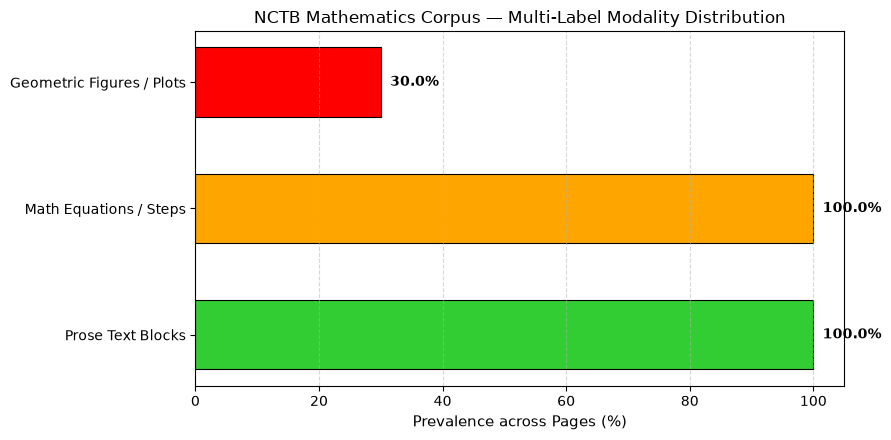

In [13]:
# Cell 6: Corpus-Wide Multi-Label Distribution Summary (Using Calibrated Hyperparameters)

print(f"Extracting multi-label layout profiles across {len(active_df)} active pages using calibrated thresholds...")
print(f"Active Configuration: {CALIBRATED_LAYOUT_CONFIG}")
layout_records = []

for idx, row in active_df.iterrows():
    seg = segment_page_regions(
        row["path"],
        min_fig_area=CALIBRATED_LAYOUT_CONFIG["min_fig_area"],
        fig_fill_thresh=CALIBRATED_LAYOUT_CONFIG["fig_fill_thresh"],
        fig_pad=CALIBRATED_LAYOUT_CONFIG["fig_pad"],
        kh_ratio=CALIBRATED_LAYOUT_CONFIG["kh_ratio"],
        heading_factor=CALIBRATED_LAYOUT_CONFIG["heading_factor"],
        math_indent_ratio=CALIBRATED_LAYOUT_CONFIG["math_indent_ratio"],
        math_fill_thresh=CALIBRATED_LAYOUT_CONFIG["math_fill_thresh"],
        text_vgap_factor=CALIBRATED_LAYOUT_CONFIG["text_vgap_factor"],
        math_vgap_factor=CALIBRATED_LAYOUT_CONFIG["math_vgap_factor"]
    )
    layout_records.append({
        "filename": row["filename"],
        "book": row["book"],
        "page_num": row["page_num"],
        "chapter": row["chapter_name_en"],
        "content_type": row["content_type"],
        "headings": seg["num_headings"],
        "text_blocks": seg["num_text"],
        "math_blocks": seg["num_math"],
        "figures": seg["num_figures"],
        "has_prose": seg["has_prose_text"],
        "has_math": seg["has_display_math"],
        "has_figures": seg["has_figures"],
        "est_words": seg["est_words"]
    })

df_layout = pd.DataFrame(layout_records)

# Multi-label prevalence rates
pct_prose = (df_layout["has_prose"].sum() / len(df_layout)) * 100
pct_math = (df_layout["has_math"].sum() / len(df_layout)) * 100
pct_figs = (df_layout["has_figures"].sum() / len(df_layout)) * 100

print("=" * 65)
print("            CALIBRATED MULTI-LABEL LAYOUT DISTRIBUTION")
print("=" * 65)
print(f"Total Pages Analyzed     : {len(df_layout)}")
print(f"Pages with Prose Text    : {df_layout['has_prose'].sum()} ({pct_prose:.1f}%)")
print(f"Pages with Math Equations: {df_layout['has_math'].sum()} ({pct_math:.1f}%)")
print(f"Pages with Figures/Plots : {df_layout['has_figures'].sum()} ({pct_figs:.1f}%)")
print("-" * 65)
print(f"Average Text Blocks/Page : {df_layout['text_blocks'].mean():.1f}")
print(f"Average Math Blocks/Page : {df_layout['math_blocks'].mean():.1f}")
print(f"Average Figures/Page     : {df_layout['figures'].mean():.1f}")
print(f"Mean Estimated Words/Page: {df_layout['est_words'].mean():.1f} ± {df_layout['est_words'].std():.1f}")
print(f"Projected Corpus Words   : ~{int(df_layout['est_words'].mean() * total_pages):,} words (704 pages)")
print("=" * 65)

# Multi-label prevalence bar chart
labels = ['Prose Text Blocks', 'Math Equations / Steps', 'Geometric Figures / Plots']
percentages = [pct_prose, pct_math, pct_figs]
colors = ['limegreen', 'orange', 'red']

plt.figure(figsize=(9, 4.5))
bars = plt.barh(labels, percentages, color=colors, height=0.55, edgecolor='black', linewidth=0.8)
plt.xlim(0, 105)
plt.xlabel('Prevalence across Pages (%)', fontsize=11)
plt.title('NCTB Mathematics Corpus — Multi-Label Modality Distribution', fontsize=12)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 1.5, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 7: Batch Bounding-Box Overlay Exporter (Saved to data/debug/layout/)

DEBUG_LAYOUT_DIR = Path("../data/debug/layout")
if not DEBUG_LAYOUT_DIR.parent.is_dir():
    DEBUG_LAYOUT_DIR = Path("data/debug/layout")

DEBUG_LAYOUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Generating full-resolution bounding-box overlay PNGs in {DEBUG_LAYOUT_DIR.resolve()}...")

color_bgr = {
    "heading": (255, 191, 0),   # Deep Sky Blue
    "text": (50, 205, 50),      # Lime Green
    "math": (0, 140, 255),      # Orange
    "figure": (0, 0, 230),      # Red
    "table": (0, 215, 255),     # Gold
}

num_exported = 0
for idx, row in active_df.iterrows():
    img_path = Path(row["path"])
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    
    seg = segment_page_regions(
        str(img_path),
        min_fig_area=CALIBRATED_LAYOUT_CONFIG["min_fig_area"],
        fig_fill_thresh=CALIBRATED_LAYOUT_CONFIG["fig_fill_thresh"],
        fig_pad=CALIBRATED_LAYOUT_CONFIG["fig_pad"],
        kh_ratio=CALIBRATED_LAYOUT_CONFIG["kh_ratio"],
        heading_factor=CALIBRATED_LAYOUT_CONFIG["heading_factor"],
        math_indent_ratio=CALIBRATED_LAYOUT_CONFIG["math_indent_ratio"],
        math_fill_thresh=CALIBRATED_LAYOUT_CONFIG["math_fill_thresh"],
        pad_y=CALIBRATED_LAYOUT_CONFIG["pad_y"],
        pad_x=CALIBRATED_LAYOUT_CONFIG["pad_x"]
    )
    
    overlay = img.copy()
    for index, r in enumerate(seg["regions"]):
        bx, by, bw, bh = r["bbox"]
        bkind = r["kind"]
        col = color_bgr.get(bkind, (0, 255, 255))
        cv2.rectangle(overlay, (bx, by), (bx + bw, by + bh), col, 2)
        tag_str = f"{index}:{bkind[0].upper()}"
        cv2.putText(overlay, tag_str, (bx, max(18, by - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2, cv2.LINE_AA)
    
    doc_subdir = DEBUG_LAYOUT_DIR / ("higher_math" if "higher" in img_path.stem else "general_math")
    doc_subdir.mkdir(parents=True, exist_ok=True)
    out_file = doc_subdir / f"{img_path.stem}.png"
    cv2.imwrite(str(out_file), overlay)
    num_exported += 1

print(f"[Done] Successfully exported {num_exported} annotated overlay images to {DEBUG_LAYOUT_DIR.resolve()}")

